In [1]:
import pandas as pd
import numpy as np
from pytrends.request import TrendReq ###-----> Google Trend'ten veri çekmek

In [2]:
pytrends = TrendReq(
    hl = "en-US",
    tz=360
)

In [5]:
keywords = ["Snowflake", "BigQuery", "Amazon Redshift", "Databricks"]

In [6]:
pytrends.build_payload(
    kw_list=keywords,
    cat=0,
    timeframe="2020-08-11 2026-08-11",
    geo="",
    gprop=""
)

In [9]:
df = pytrends.interest_over_time() 

In [26]:
df.head()

,Snowflake,BigQuery,Amazon Redshift,Databricks,isPartial
date,,,,,
2020-08-01,26,8,0,5,False
2020-09-01,86,8,1,5,False
2020-10-01,38,3,0,4,False
2020-11-01,54,2,0,3,False
2020-12-01,81,2,0,3,False


In [27]:
df.tail()

,Snowflake,BigQuery,Amazon Redshift,Databricks,isPartial
date,,,,,
2026-04-01,90,21,2,67,False
2026-05-01,86,21,3,54,False
2026-06-01,83,22,3,60,False
2026-07-01,67,16,2,47,False
2026-08-01,44,7,1,34,True


In [28]:
df.shape

(73, 5)

In [29]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 73 entries, 2020-08-01 to 2026-08-01
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Snowflake        73 non-null     int64
 1   BigQuery         73 non-null     int64
 2   Amazon Redshift  73 non-null     int64
 3   Databricks       73 non-null     int64
 4   isPartial        73 non-null     bool 
dtypes: bool(1), int64(4)
memory usage: 2.9 KB


In [30]:
df.to_csv(
    "../data/raw/multi_keyword_global_raw.csv"
)

In [31]:
df.index.min()

Timestamp('2020-08-01 00:00:00')

In [32]:
df.index.max()

Timestamp('2026-08-01 00:00:00')

In [33]:
pd.infer_freq(df.index) ### ----> Verinin haftalık olduğu bulundu W --> Weekly / SUN --> Sunday

'MS'

In [34]:
df.index.to_series().diff().value_counts()

date
31 days    42
30 days    24
28 days     5
29 days     1
Name: count, dtype: int64

In [36]:
df.isnull().sum() ### NaN kontrolü ama tarih kayıp ise yetersiz işlem

Snowflake          0
BigQuery           0
Amazon Redshift    0
Databricks         0
isPartial          0
dtype: int64

In [38]:
df.index.duplicated().sum() ### Tarih tekrarı kontrolü 

np.int64(0)

In [39]:
(df["Snowflake"] == 0).sum() 

np.int64(0)

In [40]:
(df["BigQuery"] == 0).sum() 

np.int64(0)

In [41]:
(df["Amazon Redshift"] == 0).sum() 

np.int64(22)

In [44]:
(df["BigQuery"] == 0).sum()

np.int64(0)

In [46]:
full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max()
)

full_index

DatetimeIndex(['2020-08-01', '2020-08-02', '2020-08-03', '2020-08-04',
               '2020-08-05', '2020-08-06', '2020-08-07', '2020-08-08',
               '2020-08-09', '2020-08-10',
               ...
               '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26',
               '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31', '2026-08-01'],
              dtype='datetime64[s]', length=2192, freq='D')

In [49]:
freq = pd.infer_freq(df.index)
print("Tespit edilen frekans:", freq)

Tespit edilen frekans: MS


In [55]:
### Veri setinin ilk ve son atrihi arasında buluması gereken tüm aylık tarihleri oluşturuyoruz
### Amaç ise Gerçek veri içerisinde tamamen kayıp olan bir ay varsa daha sonra buun tespit edebilmek

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq=freq
)

In [54]:
expected_count = len(full_index) ### teorik olarak bu zaman aralığında 73 ay gözlem olması gerekiyor
print("Beklenen gözlem sayısı:", expected_count)

Beklenen gözlem sayısı: 73


In [56]:
actual_count = len(df) ### Google Trend'ten çektiğimiz gerçek gözlem sayısını kontrol ediyoruz ama hala yeterli dğeil
print("gerçek gözlem sayısı:", actual_count)

gerçek gözlem sayısı: 73


In [57]:
### difference() -----> full index - gerçek index = eksik tarihler
missing_count = full_index.difference(df.index) 

In [58]:
missing_count

DatetimeIndex([], dtype='datetime64[s]', freq='MS')

In [59]:
print("Eksik tarih sayısı:", len(missing_count))

Eksik tarih sayısı: 0


## Interpolation ----> bilinen değerlerden bilinmeyeni tahmin etme yöntemi


#### Zaman serisinin haftalık frekansı kontrol edildi ve eksik timestamp tespit edilmedi. Bu nedenle interpolation uygulanmadı.

#### Ama eğer eksik değer herhangi bir hafta eksik olsaydı, o tarihte NaN değeri oluşacaktı. Bu yüzden zaman bazlı interpolation uyguluyoruz. Eksik değer yoksa veri üzerinde herhangi bir değişiklik yapmamış olacaz.

In [66]:
## Veriyi, oluşturduğumuz düzenli aylık tarih takvimine göre yeniden indeksliyoruz.
## Eğer gerçek veride tamamen eksik bir ay varsa, o tarih DataFrame'e eklenir
## ve LangChain değeri NaN olarak görünür.
columns = ["Snowflake", "BigQuery", "Amazon Redshift", "Databricks"] 
df_regular = df.reindex(full_index)
missing_count = df_regular[columns].isna().sum()  

print("Eksik gözlem sayısı:",)
print(missing_count)

Eksik gözlem sayısı:
Snowflake          0
BigQuery           0
Amazon Redshift    0
Databricks         0
dtype: int64


In [69]:
if (missing_count > 0).any(): ### .any() ---> Bunların içinde en az bir tane True var mı?
    df_regular[columns] = (
        df_regular[columns]
        .interpolate(method="time")
    )
    print("Eksik değerler interpolation ile dolduruldu.")

else:
     print("Eksik zaman noktası bulunmadı. Interpolation uygulanmadı.")

Eksik zaman noktası bulunmadı. Interpolation uygulanmadı.


In [97]:
clean_df = df.copy()

In [98]:
## Google Trends'teki tamamlanmamış dönemlere bakılıyor..
## isPartial=True olan satır, ilgili haftanın henüz tamamlanmadığını gösterir.

clean_df[clean_df["isPartial"] == True]

,Snowflake,BigQuery,Amazon Redshift,Databricks,isPartial
date,,,,,
2026-08-01,44,7,1,34,True


In [99]:
## Tamamlanmamış haftaları temiz veri setinden çıkarıyoruz.
## Çünkü henüz tamamlanmamış bir haftanın trend değeri ileride değişebilir
## ve modelleme aşamasında yanıltıcı olabilir.

clean_df = clean_df[
    clean_df["isPartial"] == False
].copy()

In [101]:
clean_df.tail()

,Snowflake,BigQuery,Amazon Redshift,Databricks,isPartial
date,,,,,
2026-03-01,72,21,3,55,False
2026-04-01,90,21,2,67,False
2026-05-01,86,21,3,54,False
2026-06-01,83,22,3,60,False
2026-07-01,67,16,2,47,False


In [102]:
clean_df.to_csv(
    "../data/processed/langchain_global_clean.csv"
)

In [103]:
clean_df.to_csv(
    "../data/processed/langchain_global_clean.csv"
)

In [104]:
clean_df.to_parquet(
    "../data/processed/langchain_global_clean.parquet"
)

# EDA

In [105]:
### Model kurmadan önce zaman serisinin genel davranışını inceliyoruz.
### Buradaki amaç tren skorunun zaman içerisinde nasıl değiştiğini görmek

In [106]:
import matplotlib.pyplot as plt

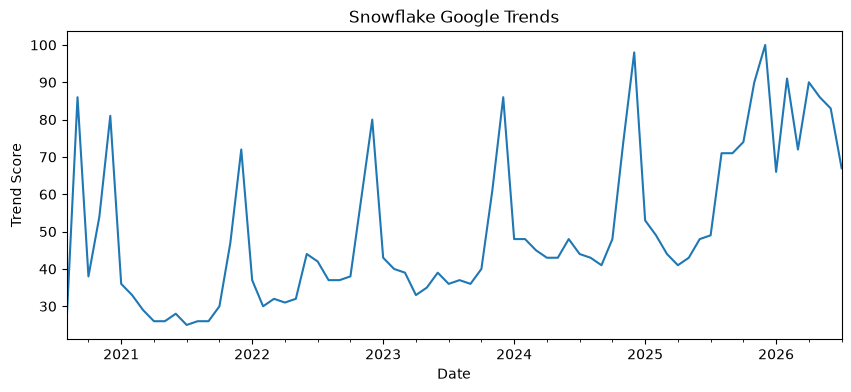

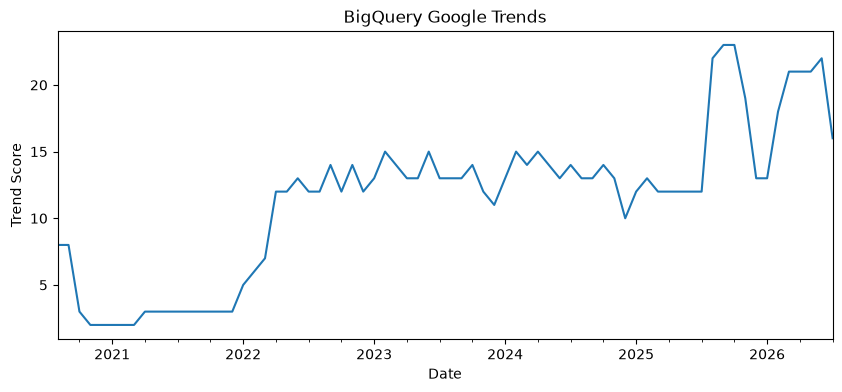

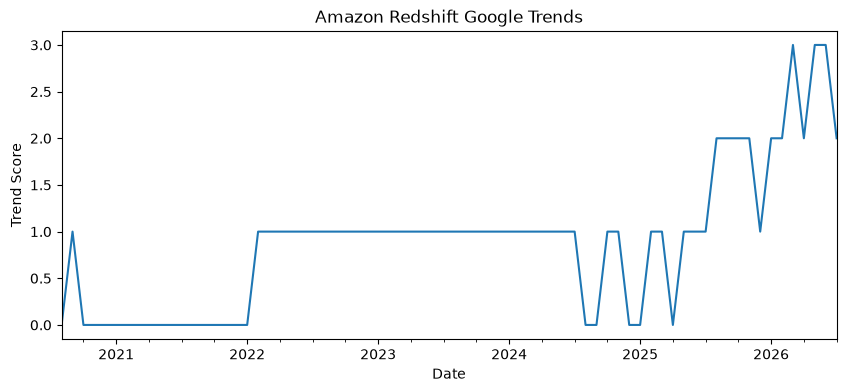

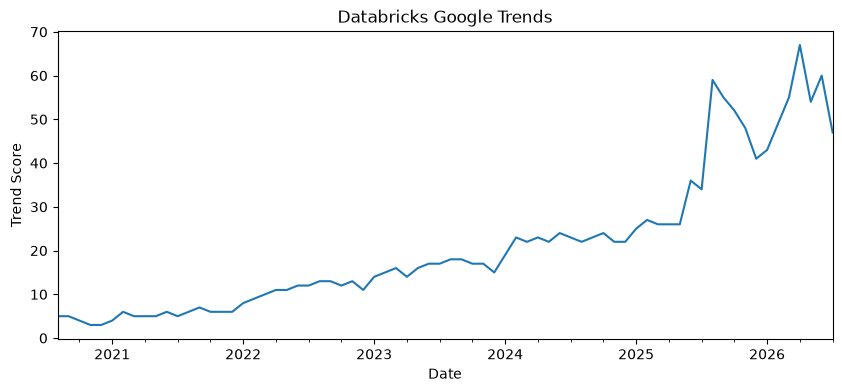

In [107]:
for column in columns:
    clean_df[column].plot(figsize=(10,4))

    plt.title(f"{column} Google Trends")
    plt.xlabel("Date")
    plt.ylabel("Trend Score")
    plt.show()

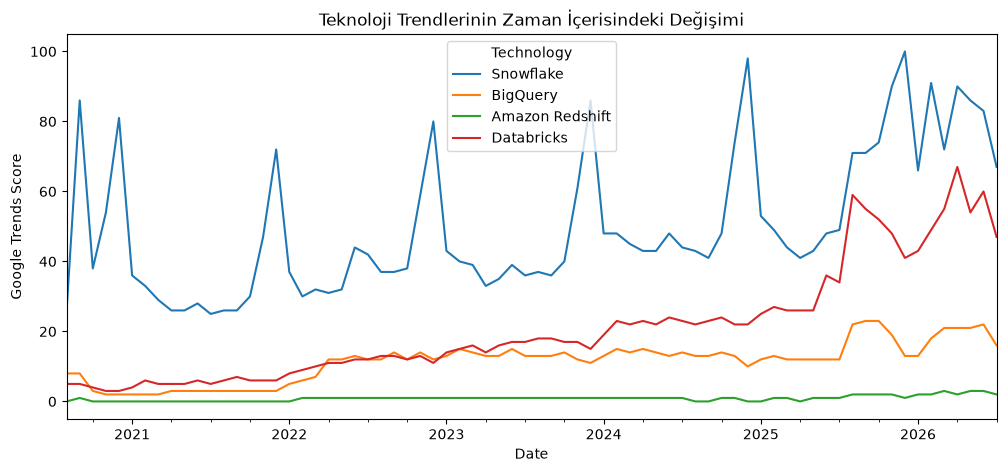

In [108]:
columns = ["Snowflake", "BigQuery", "Amazon Redshift", "Databricks"] 

clean_df[columns].plot(figsize=(12,5))

plt.title("Teknoloji Trendlerinin Zaman İçerisindeki Değişimi")
plt.xlabel("Date")
plt.ylabel("Google Trends Score")
plt.legend(title="Technology")
plt.show()

In [109]:
## Aylık veride kısa dönemli dalgalanmaları yumuşatmak için
## 3 aylık hareketli ortalama hesaplıyoruz.
##
## window=3:
## Her tarih için mevcut ay ve önceki 2 ayın
## ortalamasını hesaplar


columns = ["Snowflake", "BigQuery", "Amazon Redshift", "Databricks"] 
rolling_df =(clean_df[columns].rolling(window=3).mean())

In [110]:
rolling_df.head(10)

,Snowflake,BigQuery,Amazon Redshift,Databricks
date,,,,
2020-08-01,NaN,NaN,NaN,NaN
2020-09-01,NaN,NaN,NaN,NaN
2020-10-01,50.000000,6.333333,0.333333,4.666667
2020-11-01,59.333333,4.333333,0.333333,4.000000
2020-12-01,57.666667,2.333333,0.000000,3.333333
2021-01-01,57.000000,2.000000,0.000000,3.333333
2021-02-01,50.000000,2.000000,0.000000,4.333333
2021-03-01,32.666667,2.000000,0.000000,5.000000
2021-04-01,29.333333,2.333333,0.000000,5.333333


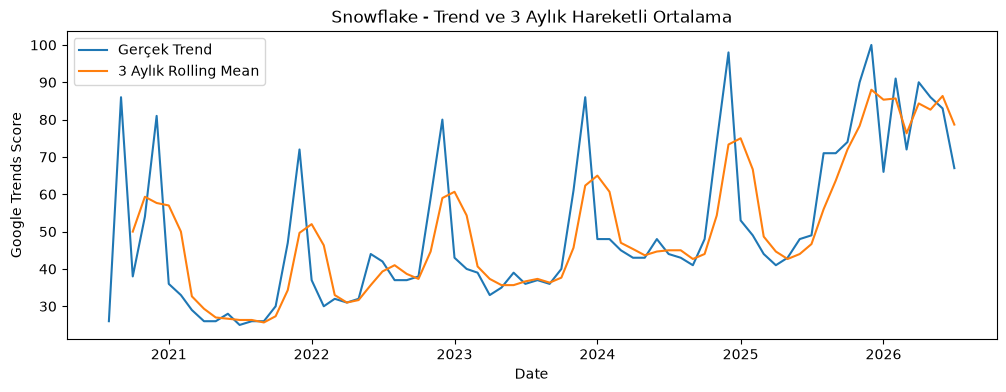

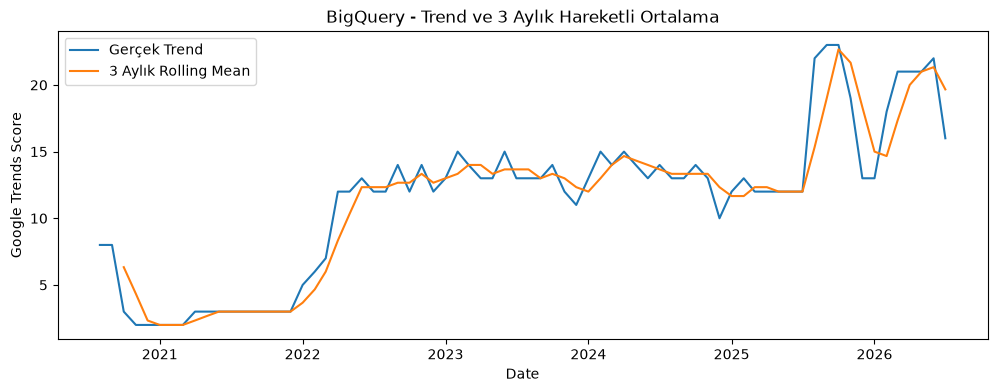

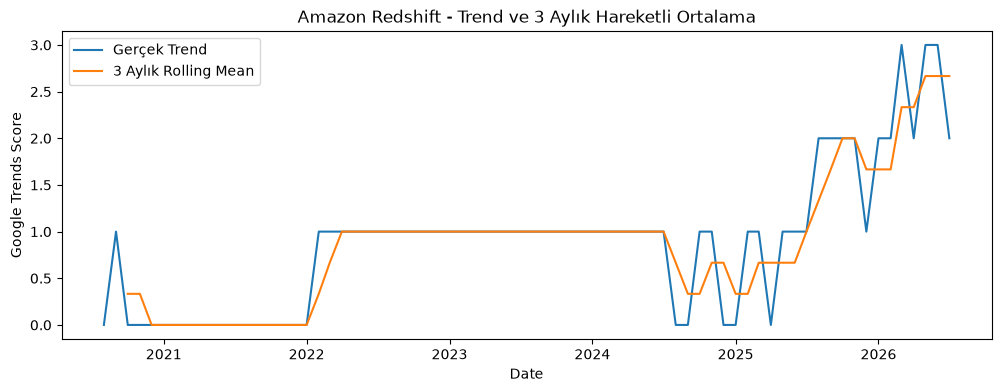

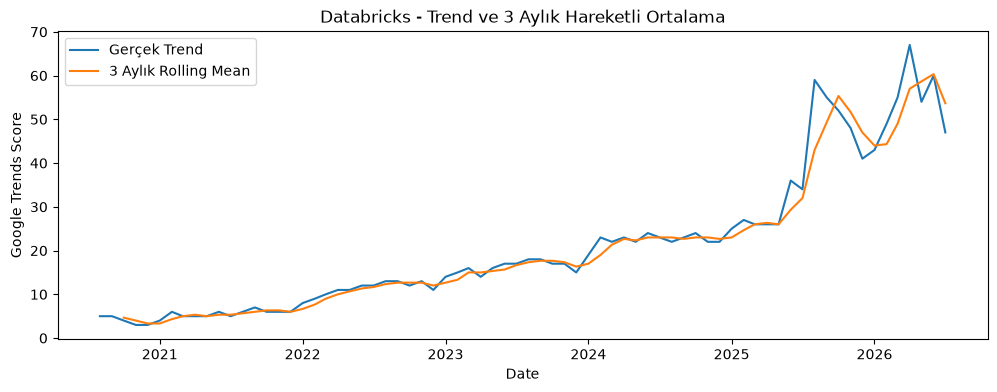

In [112]:
### 4 teknoloji için

## Her teknoloji için gerçek trend ve 3 aylık hareketli ortalamayı
## ayrı bir grafik üzerinde karşılaştırıyoruz.

for column in columns:

    plt.figure(figsize=(12, 4))

    plt.plot(
        clean_df.index,
        clean_df[column],
        label="Gerçek Trend"
    )

    plt.plot(
        rolling_df.index,
        rolling_df[column],
        label="3 Aylık Rolling Mean"
    )

    plt.title(
        f"{column} - Trend ve 3 Aylık Hareketli Ortalama"
    )

    plt.xlabel("Date")
    plt.ylabel("Google Trends Score")
    plt.legend()

    plt.show()

## Decomposition ----> Zaman serisi verisini analiz ederek trend (genel eğilim) ve sezonsallık (seasonality - örn: hafta sonu düşüşleri) bileşenlerine ayırmak

#### ayırmak için statsmodels kütüphanesindeki seasonal_decompose fonksiyonunu kullanıyoruz

In [113]:
from statsmodels.tsa.seasonal import seasonal_decompose

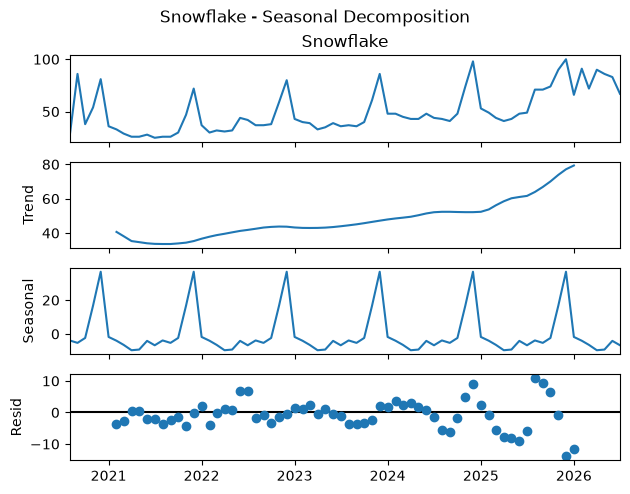

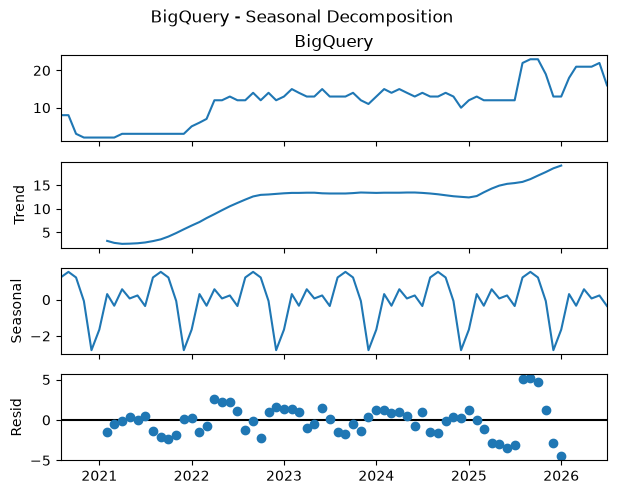

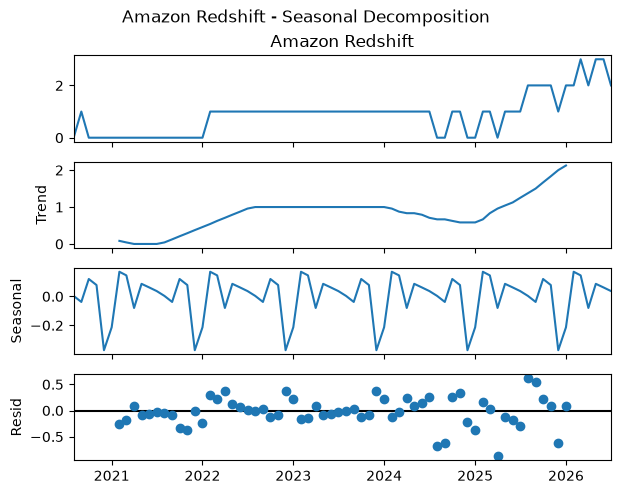

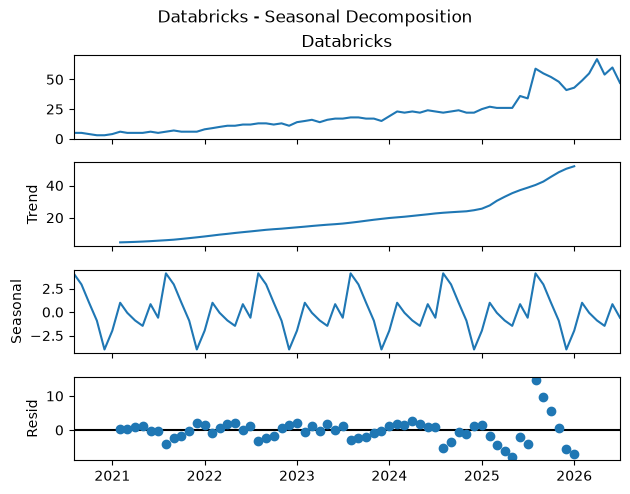

In [119]:
## Her teknoloji için ayrı ayrı decomposition uyguluyoruz.
## Böylece her serinin trend, sezonsallık ve residual yapısını
## bağımsız olarak inceleyebiliyoruz.

for column in columns:

    decomposition = seasonal_decompose(
        clean_df[column],
        model="additive",
        period=12
    )

    decomposition.plot()

    plt.suptitle(
        f"{column} - Seasonal Decomposition",
        y=1.02
    )

    plt.show()